In [147]:
import os
import math
from typing import Union, Callable, Optional
import numpy as np
try:
    import torch
    _TORCH_OK = True
except Exception:
    _TORCH_OK = False
import nibabel as nib
import scipy as sp
from scipy.ndimage import gaussian_filter, convolve
from skimage.measure import marching_cubes, mesh_surface_area
from scipy.interpolate import RegularGridInterpolator
from skimage.transform import resize
from skimage.measure import marching_cubes
from scipy.spatial import Delaunay, Voronoi, KDTree, cKDTree, QhullError
from mpl_toolkits.mplot3d.art3d import Poly3DCollection
import matplotlib.pyplot as plt
import pyvista as pv

%matplotlib inline 

In [153]:
def write_surface(V, F, filename):
    # Create a PyVista mesh from the vertices V and faces F
    mesh = pv.PolyData(V, np.c_[np.full(len(F), 3), F])
    # # Compute normals
    # mesh = mesh.compute_normals(non_manifold_traversal=False, inplace=True)
    # Save the mesh to a (e.g. VTK, STL) file
    mesh.save(filename)


def plot_surface(V,F):
    """
    F: Connectivity list (i.e. faces)
    V: Vertex coordinates (i.e. vertices)
    """
    # Display resulting triangular mesh 
    fig = plt.figure(figsize=(10, 10))
    ax = fig.add_subplot(111, projection='3d')
    mesh = Poly3DCollection(V[F], facecolor='b', edgecolor='k', alpha=0.2)
    # mesh.set_edgecolor('k')
    ax.add_collection3d(mesh)

    ax.set_xlabel("x-axis")
    ax.set_ylabel("y-axis")
    ax.set_zlabel("z-axis")

    # Set the view
    minV = np.min(V,axis=0)
    maxV = np.max(V,axis=0)
    ax.set_xlim3d(minV[0],maxV[0])
    ax.set_ylim3d(minV[1],maxV[1])
    ax.set_zlim3d(minV[2],maxV[2])
    ax.set_aspect('equal')
    # plt.tight_layout()
    plt.show()


def orient_surface(V, F, *, backend:Union[str, None]="auto", indexing="zero", epsilon=1e-9, rng=None):
    """
    Orient triangle faces consistently using a ray-parity test, mirroring the MATLAB code.

    Parameters
    ----------
    V : (N, 3) array_like
        Vertex coordinates.
    F : (M, 3) array_like (int)
        Triangle indices (faces). Can be 0- or 1-based.
    indexing : {"auto", "zero", "one"}, optional
        - "auto": try to detect if F is 1-based and convert internally if so.
        - "zero": treat F as 0-based indices (Python style).
        - "one" : treat F as 1-based indices (MATLAB style).
      Output uses the same indexing as the input mode.
    epsilon : float, optional
        Tiny offset step along the unit normal (default 1e-9).
    rng : np.random.Generator or None, optional
        Random generator for reproducibility. If None, uses np.random.default_rng().

    Returns
    -------
    F_oriented : (M, 3) ndarray (int)
        Faces with potentially flipped orientation. Indexing matches input mode.

    Notes
    -----
    This is a direct translation of daniel's MATLAB algorithm:
      1) Compute triangle centroids c and unit normals n (area-weighted, then normalized).
      2) Define test points p = c + \epsilon n.
      3) Pick a random ray direction u; for each triangle i, solve
             p + a u = q + b v + c w
         for all p simultaneously, where (q, q+v, q+w) are the triangle vertices.
         Convert to barycentric coords and count intersections (a>=0, barycentric in [0,1]).
      4) Flip faces whose intersection parity is odd.

    Performance
    ----------
    Like the MATLAB version, this loops over triangles and does a full (Mx) solve per triangle.
    Complexity is ~O(M^2). For very large meshes, consider library helpers (e.g., trimesh) or
    a more vectorized / spatially indexed approach.

    import trimesh
    mesh = trimesh.Trimesh(vertices=V, faces=F if F.min()==0 else F-1, process=False)
    trimesh.repair.fix_winding(mesh)   # or: mesh.fix_normals()
    F_out = mesh.faces

    Usage
    ----------
    # V: (N, 3) float array of vertices
    # F: (M, 3) int array of faces
    # If F came straight from MATLAB (1-based), either:
    F_out = orient_surface(V, F, indexing="one")
    # or let it auto-detect:
    F_out = orient_surface(V, F, indexing="auto")
    """

    V = np.asarray(V, dtype=float)
    F_in = np.asarray(F, dtype=int)

    # ---- Handle indexing mode ----
    if indexing not in {"auto", "zero", "one"}:
        raise ValueError('indexing must be "auto", "zero", or "one"')

    restore_one_based = False
    F_work = F_in.copy()

    if indexing == "auto":
        # Heuristic: if min>=1 and max<=len(V), assume 1-based.
        if F_work.min() >= 1 and F_work.max() <= len(V):
            F_work = F_work - 1
            restore_one_based = True
    elif indexing == "one":
        F_work = F_work - 1
        restore_one_based = True
    # else "zero": use as-is

    if backend == "trimesh":
        try:
            import trimesh
            trimesh_available = True
        except:
            trimesh_available = False
        
        if trimesh_available:
            # trimesh expects 0-based faces
            mesh = trimesh.Trimesh(vertices=V, faces=F_work, process=False)
            # Attempt to fix winding / normals
            try:
                trimesh.repair.fix_winding(mesh)
            except Exception:
                # best-effort fallback
                try:
                    mesh.fix_normals()
                except Exception:
                    pass
            F_oriented = mesh.faces.copy()
            # restore original indexing if needed
            if restore_one_based:
                F_oriented = F_oriented + 1
        else:
            raise ImportError("trimesh is not available; cannot use trimesh backend.")

        return F_oriented, np.asarray(mesh.vertices, dtype=np.float64)
    else:
        # ---- Ray direction u (unit) ----
        rng = rng if rng is not None else np.random.default_rng()
        u = rng.normal(size=3)
        nu = np.linalg.norm(u)
        if nu == 0:
            u = np.array([1.0, 0.0, 0.0])
        else:
            u = u / nu

        # ---- Triangle centroids and unit normals ----
        v0 = V[F_work[:, 0], :]
        v1 = V[F_work[:, 1], :]
        v2 = V[F_work[:, 2], :]

        c = (v0 + v1 + v2) / 3.0

        # Area-weighted normals (half cross product), then normalize
        n = np.cross(v1 - v0, v2 - v0) * 0.5
        n_norm = np.linalg.norm(n, axis=1, keepdims=True)
        # Avoid division by zero for degenerate faces
        safe = n_norm.squeeze() > 0
        n_unit = np.zeros_like(n)
        n_unit[safe] = n[safe] / n_norm[safe]

        # Test points slightly offset along normals
        p = c + epsilon * n_unit  # (M, 3)

        # ---- Intersection counting ----
        M = F_work.shape[0]
        count = np.zeros(M, dtype=np.int64)

        # For each triangle, solve for all p:
        #   p + a u = q + b v + c w
        # => p - q = -a u + b v + c w
        # Let X = [a, b, c], and A = [-u; v; w]  (3x3)
        # We want (p - q) = X * A  ==> X = (p - q) / A  (right division = multiply by inv(A))
        # In NumPy: X satisfies X @ A = (p - q)
        # Solve A^T * X^T = (p - q)^T  => X = (solve(A^T, (p - q)^T))^T
        for i in range(M):
            q = V[F_work[i, 0], :]
            v = V[F_work[i, 1], :] - V[F_work[i, 0], :]
            w = V[F_work[i, 2], :] - V[F_work[i, 0], :]

            A = np.vstack((-u, v, w))  # shape (3, 3)
            pmq = p - q  # (M, 3)

            try:
                # Solve for all rows of pmq at once (via transposes)
                X = np.linalg.solve(A.T, pmq.T).T  # X has columns [a, b, c]
            except np.linalg.LinAlgError:
                # Degenerate triangle (A singular) => contributes no intersections
                continue

            a = X[:, 0]
            b = X[:, 1]
            c_bary = X[:, 2]

            # Barycentric coords on the triangle: [1-(b+c), b, c]
            tri = np.column_stack([1.0 - (b + c_bary), b, c_bary])

            # Inside test: all barycentric coords in [0,1] <=> |coord - 0.5| <= 0.5
            inside = (np.abs(tri - 0.5) <= 0.5).sum(axis=1) == 3

            # Forward ray only: a >= 0
            hits = inside & (a >= 0.0)

            count += hits.astype(np.int64)

        # ---- Flip faces where parity is odd (inside) ----
        flip_mask = (count % 2) == 1
        F_oriented = F_work.copy()
        # Reorder columns to swap the first two indices
        F_oriented[flip_mask] = F_oriented[flip_mask][:, [1, 0, 2]]

        # ---- Restore original indexing mode ----
        if restore_one_based:
            F_oriented = F_oriented + 1

    return F_oriented



# def orient_surface(V, F):
#     """
#     Orients the faces of a mesh consistently.

#     Parameters:
#     - V: numpy array of shape (n_vertices, 3), the coordinates of the vertices.
#     - F: numpy array of shape (n_faces, 3), the indices of vertices forming each face.

#     Returns:
#     - F_oriented: numpy array of shape (n_faces, 3), the oriented faces.
#     """
#     # Compute the normal for each face
#     normals = np.cross(V[F[:, 1]] - V[F[:, 0]], V[F[:, 2]] - V[F[:, 0]])
#     # normals = np.cross(V[F[:, 0]] - V[F[:, 1]], V[F[:, 0]] - V[F[:, 2]])
#     # Compute the centroid of the mesh
#     centroid = np.mean(V, axis=0)
#     # Compute vector from face centroid to mesh centroid
#     face_centroids = np.mean(V[F], axis=1)
#     vectors = centroid - face_centroids
#     # Correct face orientation if necessary
#     dot_products = np.einsum('ij,ij->i', normals, vectors)
#     flip_faces = dot_products < 0
#     F[flip_faces] = F[flip_faces][:, [0, 2, 1]]  # Swap the last two vertices

#     # Check the volume and flip faces if needed
#     vol = np.sum(np.sum(V[np.array(F)[:, 0]] * np.cross(V[np.array(F)[:, 1]], V[np.array(F)[:, 2]]), axis=1)) / 6
#     if vol < 0:
#         F = np.asarray([ [face[0], face[2], face[1]] for face in F ])  # Swap indices 1 and 2

#     # Some of the faces are still oriented incorrectly...
#     F[flip_faces] = F[flip_faces][:, [0, 2, 1]]  # Swap the last two vertices
#     # This fixed most of the faces, but some still are incorrect...?????

#     return F


def calculate_surface_area(V, F):
    # Could also use the built-in method...
    # Calculate surface face normals
    cross_prod = np.cross(V[F[:, 1]] - V[F[:, 0]], V[F[:, 2]] - V[F[:, 0]])
    area = 0.5 * np.linalg.norm(cross_prod, axis=1)
    SA = np.sum(area)
    return SA


def select_vertices_min_distance(verts, faces, minD, nIdeal, tol=1e-13, smooth=True, workers=1, verbose=False):
    """
    Select a subset of vertices based on surface area and minimum distance constraints using KDTree.

    Args:
    - verts: (N, 3) array of vertex positions.
    - faces: (M, 3) array of face indices.
    - minD: Minimum allowed distance between selected vertices.
    - nIdeal: Ideal number of vertices to select based on surface area.
    - smooth: Boolean flag to perform averaging (smoothing) of vertex positions (optional).
    - workers: Number of workers used for computation (default is 1).
    - verbose: Boolean flag to print progress (optional).

    Returns:
    - x: (K, 3) array of selected vertex positions, where K <= nmax.
    """
    # Compute the surface area using skimage's mesh_surface_area
    SA = mesh_surface_area(verts, faces)

    # Estimate dmin and maximum number of vertices
    dmin = np.sqrt(SA / nIdeal)
    dmin = max(dmin, minD)
    nmax = int(SA / dmin / dmin * 3)
    
    if verbose:
        print('Surface Area:', SA)
        print('Estimated dmin:', dmin)
        print('nmax:', nmax)

    # Use KDTree for efficient nearest neighbor search and downsampling
    # tree = cKDTree(verts)
    tree = KDTree(verts)
    selected_indices = []
    remaining_indices = np.arange(verts.shape[0])

    while len(selected_indices) < nmax and len(remaining_indices) > 0:
        idx = remaining_indices[0]
        selected_indices.append(idx)
        # Remove neighbors within dmin
        neighbors = tree.query_ball_point(verts[idx], r=dmin, eps=tol, workers=workers)
        remaining_indices = np.setdiff1d(remaining_indices, neighbors, assume_unique=True)

        if verbose and len(selected_indices) % 10 == 0:
            print(f"Added {len(selected_indices)} of {nmax} vertices")

    x = verts[selected_indices] # downsampled vertices

    # Optional averaging (smoothing) of vertex positions
    if smooth and len(x) > 1:
        if verbose:
            print("Euclidean averaging (smoothing) vertex positions")
        from scipy.spatial import cKDTree
        tree = cKDTree(x) # build on selected points
        _, closest = tree.query(verts, workers=workers)
        x = np.vstack([
            verts[closest == i].mean(axis=0) if np.any(closest == i) else x[i]
            for i in range(len(x))
        ])

    return x

def radius_greedy_mis_fast(verts, dmin, workers=1, seed=None):
    """
    Builds a radius graph then run a randomized, greedy maximal independent set finder.
    """
    from scipy.spatial import cKDTree

    V = np.asarray(verts, np.float32)
    rng = np.random.default_rng(seed)
    order = rng.permutation(len(V))
    tree  = cKDTree(V)
    alive = np.ones(len(V), dtype=bool)
    chosen = []

    for i in order:
        if not alive[i]: 
            continue
        chosen.append(i)
        nbrs = tree.query_ball_point(V[i], dmin - 1e-7, workers=workers)
        alive[nbrs] = False

    return V[np.array(chosen, dtype=np.int64)]


def select_vertices_sequential(verts, faces, minD, nIdeal, smooth=True, tol=1e-13, verbose=False):
    """
    Select a subset of vertices based on surface area and minimum distance constraints using a sequential point addition method.
    TODO: Convert from numpy to PyKeops-based kernel distances.

    Args:
    - verts: (N, 3) array of vertex positions.
    - faces: (M, 3) array of face indices.
    - minD: Minimum allowed distance between selected vertices.
    - nIdeal: Ideal number of vertices to select based on surface area.
    - smooth: Boolean flag to perform averaging (smoothing) of vertex positions (optional).
    - tol: Tolerance for distance comparisons (optional).
    - verbose: Boolean flag to print progress (optional).

    Returns:
    - x: (K, 3) array of selected vertex positions, where K <= nmax.
    """

    # Compute the surface area using skimage's mesh_surface_area
    SA = mesh_surface_area(verts, faces)

    # Estimate dmin and maximum number of vertices
    dmin = np.sqrt(SA / nIdeal)
    dmin = max(dmin, minD)
    dmin2 = dmin * dmin  # We'll use the square of the distance to avoid computing square roots

    nmax = int(SA / dmin / dmin * 3)

    if verbose:
        print('Surface Area:', SA)
        print('Estimated dmin:', dmin)
        print('nmax:', nmax)

    # Initialize selected vertices and distances
    x = np.zeros((nmax, 3))  # To store the selected vertices
    x[0, :] = verts[0, :]  # Start with the first vertex
    count = 1  # Number of vertices selected

    # Initialize a distance array
    dist2 = np.full((verts.shape[0],), np.inf)

    while count < nmax:
        # Calculate distances from the newly added vertex to all others
        new_dist2 = np.sum((verts - x[count - 1, :]) ** 2, axis=1)
        dist2 = np.minimum(dist2, new_dist2)  # Update the minimum distance to any selected point

        # Find vertices further than dmin from all selected points
        candidates = np.where(dist2 > dmin2)[0]
        if len(candidates) == 0:
            break

        # Find the closest vertex that is more than dmin away
        ind = candidates[np.argmin(dist2[candidates])]
        # # TODO: Try this: Find the farthest vertex among the eligible that is at most dmin away
        # ind = candidates[np.argmax(dist2[candidates])]
        x[count, :] = verts[ind, :]
        count += 1

        if verbose and count % 10 == 0:
            print(f"Added vertex {count} of at most {nmax}")

    # Trim the array to the actual number of selected points
    x = x[:count, :]

    # Optional averaging (smoothing) of vertex positions
    if smooth and count > 1:
        if verbose:
            print("Averaging (smoothing) vertex positions")
        # tree = cKDTree(verts)
        tree = KDTree(verts)
        distances, closest = tree.query(verts, workers=3)
        x_new = np.zeros_like(x)
        for i in range(count):
            indices = np.where(closest == i)[0]
            if indices.size > 0:
                x_new[i, :] = np.mean(verts[indices, :], axis=0)
            else:
                x_new[i, :] = x[i, :]
        x = x_new

    return x



def select_vertices_original(verts, faces, minD, nIdeal, average=True, tol=1e-13, verbose=False):
    """
    Select a subset of vertices based on distance constraints, and optionally perform averaging.
    TODO: Convert from numpy to PyKeops-based kernel distances.

    Args:
    - verts: (N, 3) array of vertex positions.
    - SA: Surface area of the mesh.
    - minD: Minimum allowed distance between selected vertices.
    - dmin2: Squared value of the minimum distance threshold.
    - average: Boolean flag to perform optional averaging.
    - tol: Tolerance for distance comparisons (optional).
    - verbose: Boolean flag to print progress (optional).

    Returns:
    - x: (n, 3) array of selected vertex positions.
    - n: Number of vertices selected.
    """
    # Compute the surface area using skimage's mesh_surface_area
    SA = mesh_surface_area(verts, faces)

    # Estimate dmin and maximum number of vertices
    dmin = np.sqrt(SA / nIdeal)
    dmin = max(dmin, minD)
    dmin2 = dmin * dmin  # We'll use the square of the distance to avoid computing square roots

    nmax = int(SA / dmin / dmin * 3)

    if verbose:
        print('Surface Area:', SA)
        print('Estimated dmin:', dmin)
        print('nmax:', nmax)
    # Estimate nmax based on surface area and minD
    nmax = int(SA / minD / minD * 3)
    if verbose:
        print(f'nmax: {nmax}')

    # Initialize the selected vertices array
    x = np.empty((nmax, 3))
    x[0, :] = verts[0, :]  # Start with the first vertex
    count = 1  # Start count at 1 because the first point is already added

    # Initialize the distance matrix for storing distances
    dist2 = np.empty((nmax, verts.shape[0]))

    while count < nmax:
        # Find the distance of the newest added vertex to all the others
        dist2[count - 1, :] = np.sum(np.power(x[count - 1, :].reshape(3,1) - verts.T, 2), axis=0)

        # Check if any vertices are farther than dmin2 from all selected vertices
        mindist = np.min(dist2[:count, :], axis=0)  # Use count to include all added points
        mindistGTDMin2 = mindist > dmin2
        if not np.any(mindistGTDMin2):
            break  # No vertices farther than dmin2, so we stop
        
        # Find the closest vertex that is more than dmin away
        themin = np.min(mindist[mindistGTDMin2])
        test = [i for i, dist in enumerate(mindist) if np.abs(dist - themin) < tol]
        
        # If no valid vertex found, break out of the loop
        if len(test) == 0:
            break
        
        # Add the selected vertex to x if it's valid
        if test[0] < verts.shape[0]:
            x[count, :] = verts[test[0], :]
            count += 1
        else:
            if verbose:
                print(f"Invalid index: {test[0]}")
    
    # Trim the x array to the actual number of points added
    x = x[:count, :]  # Use count to include all added points

    # Optional averaging of vertex positions
    if average and count > 1:
        if verbose:
            print("Averaging vertex positions")
        tree = KDTree(x)
        distances, closest = tree.query(verts, workers=3)
        x_new = np.zeros_like(x)
        for i in range(count):
            indices = np.where(closest == i)[0]
            if indices.size > 0:
                x_new[i, :] = np.mean(verts[indices, :], axis=0)
            else:
                x_new[i, :] = x[i, :]  # Keep original if no neighbors found
        x = x_new

    # Return the selected vertices and the number of vertices selected
    return x, count


def _hexpack_fill(SA, minD=None, k=None):
    """
    Make minD and k consistent via hex packing on a 2D surface.

    SA: surface area of entire surface
    A_cell: area of a 2D Coronoi cell
    K: target count 
    minD: min distance between two vertices
    A_cell = (math.sqrt(3)/2)*dmin*dmin 
    => dmin \approx math.sqrt( (2/math.sqrt(3)) * SA / K )
    => K \approx (2/math.sqrt(3)) * SA / (dmin*dmin)
    """
    if minD is None and k is None:
        raise ValueError("Provide at least one of minD or k (and faces to compute SA).")
    if minD is not None and k is not None:
        # Trust the user; don't override. Still return both.
        return float(minD), int(k)
    if minD is None:
        # infer minD from k
        d = math.sqrt((2.0 / math.sqrt(3.0)) * SA / float(k))
        return float(d), int(k)
    else:
        # infer k from minD
        k_est = (2.0 / math.sqrt(3.0)) * SA / (float(minD) ** 2)
        return float(minD), int(round(k_est))
    

def fps_threshold(verts, faces, minD=None, k=None, seed=0, device=None, return_indices=False, verbose=False, eps=1e-7):
    """
    Farthest-Point Sampling (FPS) with early stop at minD or fixed k.
    - If `faces` is provided, we use its surface area to make (minD, k) consistent via hex packing.
    - If only one of {minD, k} is given, the other is inferred from SA.
    - If neither faces nor a consistent pair is provided, we just honor the given {minD, k}.

    Returns:
        pts [K,3] (and idx [K] if return_indices=True)

    TODO: 
    1) post-process using one iter of surface Lloyd relaxation to improve area coverage, the reenforce dmin constraint.
    2) employ diagnostics printed when verbose (e.g. dmin constraint check, uniformity, spectrum)
    3) surface-aware distance post-processing option?

    """
    V_np = np.asarray(verts, dtype=np.float32)
    N = V_np.shape[0] # this is the number of vertices from the original marching cubes run
    if N == 0:
        return (V_np, np.array([], dtype=int)) if return_indices else V_np

    # Surface area (optional)
    SA = None
    if faces is not None:
        # Compute the surface area using skimage's mesh_surface_area
        SA = float(mesh_surface_area(V_np, np.asarray(faces, dtype=np.int64)))

    # If we can, make minD and k consistent
    if SA is not None:
        minD, k = _hexpack_fill(SA, minD=minD, k=k)
        if verbose:
            print(f"[fps] SA={SA:.3f}, hex-pack => minD={minD:.6g}, k≈{k}")
    else:
        if verbose and (minD is None and k is None):
            print("[fps] No faces/SA; running with the provided minD/k as-is.")

    # Decide backend
    if device is None:
        device = "cuda" if (_TORCH_OK and torch.cuda.is_available()) else "cpu"

    # If torch absent or the user forces pure CPU, run NumPy
    if device == "cpu" and not _TORCH_OK:
        if verbose:
            print("[fps] Backend: NumPy (torch not available)")
        rng = np.random.default_rng(seed)
        # Better first center: farthest from centroid
        c = V_np.mean(axis=0)
        d2 = np.sum((V_np - c) ** 2, axis=1)
        start = int(np.argmax(d2))
        chosen = [start]
        d2 = np.sum((V_np - V_np[start]) ** 2, axis=1)

        # Stopping rules
        r2 = None if minD is None else float(minD * minD)
        Kmax = N if k is None else int(k)

        while len(chosen) < Kmax:
            i = int(np.argmax(d2))
            if r2 is not None and d2[i] < r2 - eps:
                break
            chosen.append(i)
            diff = V_np - V_np[i]
            # Update running min distance^2
            d2 = np.minimum(d2, np.einsum('ij,ij->i', diff, diff))
        pts = V_np[np.array(chosen, dtype=np.int64)]
        return (pts, np.array(chosen, dtype=np.int64)) if return_indices else pts

    # PyTorch path (CPU or CUDA)
    if not _TORCH_OK:
        raise RuntimeError("device != 'cpu' requested, but PyTorch is not available.")

    if verbose:
        print(f"[fps] Backend: PyTorch ({device})")

    V = torch.as_tensor(V_np, dtype=torch.float32, device=device)

    # Better first center: farthest from centroid (should yield less variance)
    centroid = V.mean(dim=0)
    d2 = torch.sum((V - centroid) ** 2, dim=1)
    start = int(torch.argmax(d2))
    chosen = [start]

    # Initialize d2 as distance^2 to first center
    d2 = torch.sum((V - V[start]) ** 2, dim=1)

    r2 = None if minD is None else float(minD * minD)
    Kmax = N if k is None else int(k)

    # Main loop
    while len(chosen) < Kmax:
        i = int(torch.argmax(d2))
        if r2 is not None and float(d2[i]) < r2 - eps:
            break
        chosen.append(i)
        # In-place update helps a bit
        diff = V - V[i]
        cand = torch.sum(diff * diff, dim=1)
        d2 = torch.minimum(d2, cand)

    idx = torch.tensor(chosen, dtype=torch.int64, device=device)
    pts = V.index_select(0, idx).detach().cpu().numpy()
    if return_indices:
        return pts, idx.cpu().numpy()
    return pts


    import torch
from pytorch3d.ops import sample_farthest_points

# ---------------------------
# Helpers
# ---------------------------

def _grid_hash(points, cell_size):
    """Return (keys:int64[N], cell_coords:int64[N,3], origin:float[3], shifts:tuple(int,int))."""
    pmin = points.min(0).values
    gcoords = torch.floor((points - pmin) / cell_size).to(torch.int64)  # (N,3)

    # Make nonnegative and compute safe bit shifts
    gmin = gcoords.min(0).values
    g = gcoords - gmin
    grng = g.max(0).values + 1
    # 21/42-bit windows are safe for typical ranges; adapt if huge
    sy = max(int(torch.ceil(torch.log2(grng[0:1].clamp_min(2).float())).item()), 21)
    sz = max(int(torch.ceil(torch.log2(grng[1:2].clamp_min(2).float())).item()) + sy, 42)

    keys = (g[:, 0] << sy) ^ (g[:, 1]) ^ (g[:, 2] << sz)
    return keys, g, pmin, (sy, sz)

def _group_by_key(keys):
    """Return: uniq_keys[K], inv[N], order[N], starts[K], counts[K]."""
    uniq, inv = torch.unique(keys, sorted=True, return_inverse=True)
    order = torch.argsort(inv)
    inv_sorted = inv[order]
    uniq_consec, counts = torch.unique_consecutive(inv_sorted, return_counts=True)
    starts = torch.cat([torch.tensor([0], device=keys.device), counts.cumsum(0)[:-1]])
    # uniq_consec should be 0..K-1 in order
    return uniq, inv, order, starts, counts

def _enumerate_neighbor_codes(cell_coords_unique, shifts, halo_cells=1):
    """
    cell_coords_unique: (B,3) int64 coordinates for each cell
    Return dict: cell_id -> list of neighbor cell_ids (including itself).
    """
    device = cell_coords_unique.device
    sy, sz = shifts
    # Build a map from coord->id
    coord_to_id = {}
    # Pack to key the same way we hashed (but using the shifted nonnegative coords)
    for i in range(cell_coords_unique.shape[0]):
        cx, cy, cz = cell_coords_unique[i].tolist()
        key = (int(cx) << sy) ^ int(cy) ^ (int(cz) << sz)
        coord_to_id[key] = i

    offsets = torch.stack(torch.meshgrid(
        torch.arange(-halo_cells, halo_cells + 1, device=device),
        torch.arange(-halo_cells, halo_cells + 1, device=device),
        torch.arange(-halo_cells, halo_cells + 1, device=device),
        indexing="ij"
    ), dim=-1).reshape(-1, 3)  # ((2h+1)^3, 3)

    neighbors = [[] for _ in range(cell_coords_unique.shape[0])]
    for i in range(cell_coords_unique.shape[0]):
        base = cell_coords_unique[i]
        for d in offsets:
            nb = base + d
            key = (int(nb[0]) << sy) ^ int(nb[1]) ^ (int(nb[2]) << sz)
            j = coord_to_id.get(key, None)
            if j is not None:
                neighbors[i].append(j)
    return neighbors

def _pack_padded(points_sorted, order, starts, counts):
    """Pack per-cell ragged lists into (B,maxlen,3), lengths[B], and index map (B,maxlen)->global idx."""
    device = points_sorted.device
    B = counts.numel()
    maxlen = int(counts.max().item())
    padded = points_sorted.new_zeros((B, maxlen, 3))
    idx_padded = torch.full((B, maxlen), -1, dtype=torch.int64, device=device)
    for b in range(B):
        n_b = int(counts[b].item())
        if n_b == 0:
            continue
        s = starts[b]
        sl = order[s:s + n_b]
        padded[b, :n_b] = points_sorted[s:s + n_b]
        idx_padded[b, :n_b] = sl
    lengths = counts.clone()
    return padded, idx_padded, lengths

def _distribute_quotas(counts, target_K, weights=None):
    """
    counts: (#cells,)
    weights: optional per-cell weights (sum positive)
    Return integer quotas summing to target_K (cap by counts).
    """
    device = counts.device
    if weights is None:
        w = counts.float()
    else:
        w = weights.float().clamp_min(0)

    if w.sum() == 0:
        q = torch.zeros_like(counts, dtype=torch.int64)
        q[counts.argmax()] = min(int(target_K), int(counts.max().item()))
        return q

    w = w / w.sum()
    raw = w * target_K
    q = torch.floor(raw).to(torch.int64)
    # Cap by available points in the cell
    q = torch.minimum(q, counts.to(torch.int64))
    # Fix remainder
    remainder = target_K - int(q.sum().item())
    if remainder > 0:
        frac = (raw - q.float())
        # Mask cells that are already at cap
        cap_mask = (q < counts)
        frac = torch.where(cap_mask, frac, torch.tensor(-1.0, device=device))
        k = min(remainder, int((cap_mask).sum().item()))
        if k > 0:
            topk = torch.topk(frac, k=k, largest=True).indices
            q[topk] += 1
    return q

def _radius_groups(points, ref_idx, radius, cell_size=None):
    """
    Build neighbor lists for each reference index within 'radius' using a simple grid binning.
    Returns a list of 1D index tensors (variable length).
    """
    device = points.device
    if cell_size is None:
        cell_size = max(radius, 1e-6)
    keys, gcoords, pmin, shifts = _grid_hash(points, cell_size)
    _, inv, order, starts, counts = _group_by_key(keys)
    # map from cell id to slice of 'order'
    cell_to_slice = [(int(starts[i].item()), int((starts[i] + counts[i]).item())) for i in range(counts.numel())]

    # Helper to collect candidate points from neighbor cells
    uniq_coords = torch.unique(gcoords, dim=0)
    # Build a map coord->id for neighbors
    sy, sz = shifts
    coord_to_id = {}
    for i in range(uniq_coords.shape[0]):
        cx, cy, cz = uniq_coords[i].tolist()
        key = (int(cx) << sy) ^ int(cy) ^ (int(cz) << sz)
        coord_to_id[key] = i
    neighbors = _enumerate_neighbor_codes(uniq_coords, shifts, halo_cells=1)

    # Map each point's cell (in uniq order)
    # First, rebuild for each point the uniq cell id
    # We can use the same hashing used for uniq mapping by re-encoding:
    key_all = (gcoords[:, 0] << sy) ^ gcoords[:, 1] ^ (gcoords[:, 2] << sz)
    uniq_keys, inv_point_to_cell = torch.unique(key_all, return_inverse=True)

    r2 = radius * radius
    groups = []
    for idx in ref_idx.tolist():
        cid = int(inv_point_to_cell[idx].item())
        # gather candidates from this cell + neighbors (in uniq indexing)
        cand_ids = neighbors[cid] if cid < len(neighbors) else [cid]
        cand_points = []
        for nb in cand_ids:
            # Need to find the matching uniq key -> but we didn't store mapping to 'order' slices for uniq order.
            # Approximation: collect all points whose inv_point_to_cell == nb (linear mask is OK for K << N calls).
            mask = (inv_point_to_cell == nb)
            cand_points.append(torch.nonzero(mask, as_tuple=False).squeeze(1))
        cand_idx = torch.cat(cand_points) if cand_points else torch.tensor([], dtype=torch.int64, device=device)
        if cand_idx.numel() == 0:
            groups.append(torch.tensor([idx], device=device, dtype=torch.int64))
            continue
        d2 = (points[cand_idx] - points[idx]).pow(2).sum(-1)
        keep = cand_idx[d2 <= r2]
        if keep.numel() == 0:
            keep = torch.tensor([idx], device=device, dtype=torch.int64)
        groups.append(keep)
    return groups

def _surface_lloyd_one_step(points, chosen_idx, radius, snap_to_input=True):
    """
    One iteration: for each chosen point i, compute centroid of neighbors within radius,
    then (optionally) snap to nearest original point to keep index semantics.
    Returns updated indices (unique preserved by later reconcile).
    """
    if chosen_idx.numel() == 0:
        return chosen_idx
    groups = _radius_groups(points, chosen_idx, radius)
    device = points.device
    new_pos = []
    for g in groups:
        new_pos.append(points[g].mean(dim=0, keepdim=True))
    new_pos = torch.cat(new_pos, dim=0)  # (K,3)

    if not snap_to_input:
        # Return a fresh set of coordinates (then you'd need downstream handling)
        # Here we keep indices, so we'll always snap.
        pass

    # Snap: for each new_pos, find nearest original point (brute-force over candidates from local grid)
    # Use the same local groups again for speed
    snapped = []
    for i, g in enumerate(groups):
        dif = points[g] - new_pos[i]
        j = torch.argmin((dif * dif).sum(-1))
        snapped.append(g[j])
    snapped = torch.stack(snapped, dim=0)
    return snapped

# ---------------------------
# Main API
# ---------------------------

@torch.no_grad()
def hybrid_fps_pytorch3d(
    points: torch.Tensor,             # (N,3), float32
    K: int,                           # final number of samples
    dmin: float,                      # target spacing scale (also sets default cell size)
    *,
    device: str | None = None,
    cell_size: float | None = None,   # default: dmin
    halo_cells: int = 1,              # 0 = no halo; 1 = 26-neighborhood
    use_halo: bool = True,            # toggle halo inclusion
    area_weights_per_point: torch.Tensor | None = None,  # optional (N,)
    run_surface_lloyd: bool = False,  # toggle the Lloyd smoothing step
    lloyd_radius_factor: float = 1.0  # neighborhood radius = factor * dmin
):
    """
    DFPS-style grid partition + optional HALO + batched local FPS + global reconcile + optional surface-Lloyd.
    Returns indices into `points` (length K or <=K if N<K).
    """
    assert points.ndim == 2 and points.shape[1] == 3
    N = points.shape[0]
    if K >= N:
        return torch.arange(N, device=points.device)

    if device is None:
        device = points.device
    points = points.to(device)
    if area_weights_per_point is not None:
        area_weights_per_point = area_weights_per_point.to(device)

    if cell_size is None:
        cell_size = float(dmin)

    # 1) Grid + groups
    keys, gcoords, pmin, shifts = _grid_hash(points, cell_size)
    uniq_keys, inv, order, starts, counts = _group_by_key(keys)

    # Optional per-cell weights
    if area_weights_per_point is None:
        per_cell_weight = counts.float().clone()
    else:
        per_cell_weight = torch.zeros_like(counts, dtype=torch.float32)
        per_cell_weight.scatter_add_(0, inv[order], area_weights_per_point[order])

    # 2) If halo is on: build per-cell augmented membership (cell + neighbors)
    # We implement halo by *batching* each cell with points from its neighbor cells.
    if use_halo and halo_cells > 0:
        # unique cell coords in the same order as uniq_keys
        # Reconstruct coords for uniq cells: take first coord of each run
        # (more direct: compute unique on gcoords with return_inverse, but we already have uniq order)
        # Grab the first coord of each cell from the sorted arrays
        cell_first = order[starts]  # (B,)
        uniq_cell_coords = gcoords[cell_first]  # (B,3)
        neighbors = _enumerate_neighbor_codes(uniq_cell_coords, shifts, halo_cells=halo_cells)

        # Build augmented index lists per cell
        cell_to_points = []
        inv_point_to_cell = inv  # each point's base cell id (0..B-1)
        for cid in range(len(neighbors)):
            # candidate cells = this + neighbors
            nbs = neighbors[cid]
            mask = torch.zeros(N, dtype=torch.bool, device=device)
            # mark points belonging to any neighbor cell
            for nb in nbs:
                mask |= (inv_point_to_cell == nb)
            idxs = torch.nonzero(mask, as_tuple=False).squeeze(1)
            cell_to_points.append(idxs)
        # Pack to padded tensors (B, maxlen, 3)
        B = len(cell_to_points)
        maxlen = max(int(x.numel()) for x in cell_to_points) if B > 0 else 0
        padded = points.new_zeros((B, maxlen, 3))
        idx_padded = torch.full((B, maxlen), -1, dtype=torch.int64, device=device)
        lengths = torch.zeros(B, dtype=torch.int64, device=device)
        for b, idxs in enumerate(cell_to_points):
            n_b = int(idxs.numel())
            if n_b == 0:
                continue
            padded[b, :n_b] = points[idxs]
            idx_padded[b, :n_b] = idxs
            lengths[b] = n_b
        # quotas per cell based on base-cell weights (not augmented counts)
        quotas = _distribute_quotas(counts, K, weights=per_cell_weight)
        quotas = torch.clamp(quotas, max=(lengths > 0).to(torch.int64) * lengths.max().item())
        K_b = quotas
        # Remove empty batch rows
        keep = lengths > 0
        if keep.any():
            padded = padded[keep]
            idx_padded = idx_padded[keep]
            lengths = lengths[keep]
            K_b = K_b[keep]
        else:
            # Fallback: one-shot global FPS
            _, idx = sample_farthest_points(points[None, ...], K=K)
            return idx[0]
    else:
        # No halo: just pack per-cell native members
        points_sorted = points[order]
        padded, idx_padded, lengths = _pack_padded(points_sorted, order, starts, counts)
        quotas = _distribute_quotas(counts, K, weights=per_cell_weight)
        K_b = quotas

    # 3) Batched local FPS (one kernel)
    if lengths.numel() == 0 or int(lengths.sum().item()) == 0:
        _, idx = sample_farthest_points(points[None, ...], K=K)
        return idx[0]

    K_b = torch.clamp(K_b, min=0)
    if K_b.sum() == 0:
        _, idx = sample_farthest_points(points[None, ...], K=K)
        return idx[0]

    K_max = int(K_b.max().item())
    _, local_idx = sample_farthest_points(padded, K=K_max, lengths=lengths)

    # Gather local candidates back to global indices
    cand_list = []
    for b in range(padded.shape[0]):
        kk = int(K_b[b].item())
        if kk <= 0:
            continue
        pick_local = local_idx[b, :kk]
        pick_global = idx_padded[b].gather(0, pick_local)
        cand_list.append(pick_global)
    candidates = torch.cat(cand_list, dim=0) if len(cand_list) else torch.empty(0, dtype=torch.int64, device=device)

    # 4) Optional surface-Lloyd (one step, then we'll reconcile)
    if run_surface_lloyd and candidates.numel() > 0:
        r_lloyd = float(lloyd_radius_factor) * float(dmin)
        candidates = _surface_lloyd_one_step(points, candidates, radius=r_lloyd, snap_to_input=True)

    # 5) Global reconcile on the reduced set (enforce separation and remove duplicates)
    candidates = torch.unique(candidates, sorted=False)  # cheap dedupe
    k_final = min(K, candidates.numel())
    if k_final == 0:
        _, idx = sample_farthest_points(points[None, ...], K=K)
        return idx[0]
    cand_pts = points[candidates][None, :, :]
    _, idx_final_local = sample_farthest_points(cand_pts, K=k_final)
    final_idx = candidates[idx_final_local[0]]
    return final_idx




def grid_based_sampling_old(verts, dmin):
    """
    Grid-based Poisson Disk Sampling.
    """
    # Compute grid dimensions
    cell_size = dmin / np.sqrt(3)
    min_corner = verts.min(axis=0)
    max_corner = verts.max(axis=0)
    grid_shape = np.ceil((max_corner - min_corner) / cell_size).astype(int)
    grid = {}

    selected_points = []
    for point in verts:
        grid_coord = tuple(((point - min_corner) / cell_size).astype(int))
        is_valid = True
        # Check neighboring cells
        for dx in [-1, 0, 1]:
            for dy in [-1, 0, 1]:
                for dz in [-1, 0, 1]:
                    neighbor = (grid_coord[0]+dx, grid_coord[1]+dy, grid_coord[2]+dz)
                    if neighbor in grid:
                        neighbor_point = grid[neighbor]
                        if np.linalg.norm(point - neighbor_point) < dmin:
                            is_valid = False
                            break
                if not is_valid:
                    break
            if not is_valid:
                break
        if is_valid:
            grid[grid_coord] = point
            selected_points.append(point)

    x = np.array(selected_points)
    return x

def grid_based_sampling(verts, dmin, seed=None):
    """
    Greedy grid-based culling with correct neighbor reach.
    Ensures ||xi - xj|| >= dmin (up to floating-point).
    """
    verts = np.asarray(verts, dtype=np.float32)
    rng = np.random.default_rng(seed)
    order = rng.permutation(len(verts))
    V = verts[order]

    # cell size as in Bridson: ensures at most one sample per cell is sufficient
    cell = dmin / np.sqrt(3.0)
    inv_cell = 1.0 / cell
    r2 = (dmin * dmin)

    # jitter the grid origin to reduce lattice artifacts
    min_corner = V.min(axis=0) - rng.uniform(0.0, cell, size=3).astype(np.float32)

    # With this cell size, we must check ±2 in each axis
    reach = int(math.ceil(dmin / cell))  # = 2

    grid = {}  # dict[(ix,iy,iz)] -> sample point (np.float32[3])
    chosen_idx = []

    for j, p in enumerate(V):
        g = ((p - min_corner) * inv_cell).astype(np.int32)
        ok = True

        # scan neighbors
        for dx in range(-reach, reach + 1):
            if not ok: break
            for dy in range(-reach, reach + 1):
                if not ok: break
                for dz in range(-reach, reach + 1):
                    q = grid.get((g[0] + dx, g[1] + dy, g[2] + dz))
                    if q is not None:
                        d2 = np.dot(p - q, p - q)
                        if d2 < r2:  # use <= if you want strictly greater than
                            ok = False
                            break
        if ok:
            grid[(g[0], g[1], g[2])] = p  # one per cell is sufficient here
            chosen_idx.append(order[j])

    return verts[np.array(chosen_idx, dtype=np.int64)]


def identify_thin_surfaces(vertices, faces, thickness_threshold=0.5):
    """
    Identifies thin surfaces in a mesh based on a thickness threshold.
    """

    thin_faces = []

    for face in faces:
        # Calculate the face normal
        face_normal = np.cross(vertices[face[1]] - vertices[face[0]], 
                                vertices[face[2]] - vertices[face[0]])
        face_normal /= np.linalg.norm(face_normal)

        # Calculate the thickness by projecting vertices onto the normal
        thickness = np.max(np.abs(np.dot(vertices - vertices[face[0]], face_normal)))

        if thickness < thickness_threshold:
            thin_faces.append(face)

    return thin_faces


def _normalize_unit_box(X):
    X = np.asarray(X, np.float64)
    mn = X.min(axis=0); mx = X.max(axis=0)
    span = mx - mn
    # avoid zero-span in any axis
    span[span == 0.0] = 1.0
    Y = (X - mn) / span  # [0,1]^3
    return Y, mn, span

def _denormalize_unit_box(Y, mn, span):
    return Y * span + mn

def _unique_rows_tol_grid(X, tol=1e-12):
    """Fast near-duplicate cull via quantization; tol is in L2 units of bbox diag."""
    X = np.asarray(X, np.float64)
    if X.size == 0:
        return X
    # scale by bbox diag to get a dimensionless rounding
    diag = np.linalg.norm(np.ptp(X,axis=0))
    s = tol * (diag if diag > 0 else 1.0)
    if s == 0:
        return X
    Q = np.round(X / s)
    _, idx = np.unique(Q, axis=0, return_index=True)
    return X[np.sort(idx)]

def _tiny_jitter(X, mag=1e-9, seed=0):
    X = np.asarray(X, np.float64)
    rng = np.random.default_rng(seed)
    span = X.ptp(axis=0)
    scale = np.linalg.norm(span) or 1.0
    return X + rng.standard_normal(X.shape) * (mag * scale)

def robust_delaunay_points(
    X_in,
    qh_base_opts="Qt Qbb Qc",       # current Matlab-like base
    use_Qx=True,                    # exact merges
    first_try_with_QJ=True,         # joggle on first attempt
    tol_dedupe=1e-12,               # near-duplicate tolerance (bbox-diag units)
    jitter_seq=(1e-10, 5e-10, 1e-9),
    add_small_hull=False,           # usually False
    hull_scale=1.5,                 # if True, add cube corners just outside [0,1]^3 in normalized space
    verbose=False
):
    # 1) float64, remove non-finite
    X = np.asarray(X_in, np.float64)
    X = X[np.isfinite(X).all(axis=1)]
    if X.shape[0] < 4:
        raise ValueError("Need at least 4 points for 3D Delaunay")

    # 2) normalize to unit box
    Y, mn, span = _normalize_unit_box(X)

    # 3) cull near-duplicates in normalized coords
    Y = _unique_rows_tol_grid(Y, tol=tol_dedupe)

    # 4) optional tiny normalized hull (daniel's original used a hull at +-1e6)
    if add_small_hull:
        # corners slightly outside unit cube (kept small to avoid conditioning issues)
        c = np.array([[0,0,0],[0,0,1],[0,1,0],[0,1,1],[1,0,0],[1,0,1],[1,1,0],[1,1,1]], dtype=np.float64)
        ctr = 0.5
        sc = hull_scale  # e.g., 1.5 => corners at [-0.25, 1.25], modestly outside
        hull = ctr + (c - ctr) * sc
        Y_all = np.vstack([Y, hull])
        nh = hull.shape[0]
    else:
        Y_all = Y
        nh = 0

    # 5) choose options
    opts = qh_base_opts
    if use_Qx and "Qx" not in opts:
        opts = (opts + " Qx")
    if first_try_with_QJ and "QJ" not in opts:
        opts_try = (opts + " QJ")
    else:
        opts_try = opts

    # 6) try sequence: (opts_try) -> jitter retries -> (opts + QJ) as last resort
    def _try(Ycur, opts_):
        if verbose:
            print(f"[Delaunay] trying opts='{opts_}' on n={len(Ycur)}")
        return Delaunay(Ycur, qhull_options=opts_)

    try:
        DT = _try(Y_all, opts_try)
    except QhullError as e:
        if verbose:
            print(f"[Delaunay] fail with opts='{opts_try}': {type(e).__name__}")
        # external jitter retries (IMPORTANT: jitter in normalized coords)
        for mag in jitter_seq:
            try:
                DT = _try(_tiny_jitter(Y_all, mag=mag), opts_try)
                break
            except QhullError:
                DT = None
        if DT is None:
            # final attempt: ensure QJ present
            try:
                DT = _try(Y_all, opts if "QJ" in opts else (opts + " QJ"))
            except QhullError as e2:
                raise RuntimeError("Delaunay failed after robust fallbacks") from e2

    # 7) return triangulation in original coordinates (simplices are index-based)
    return DT, Y_all, mn, span


def _tetrahedron_circumcenters(points, tets, eps_vol=0.0):
    """
    x: (N,3) float64 vertices
    T: (M,4) int tetrahedra
    returns: (M,3) circumcenters
    """
    # Ensure float64 (important for Qhull-scale problems)
    points = np.asarray(points, dtype=np.float64)
    tets = np.asarray(tets, dtype=np.int64)
    p1 = points[tets[:, 0], :] # (M,3)
    p2 = points[tets[:, 1], :]
    p3 = points[tets[:, 2], :]
    p4 = points[tets[:, 3], :]
    a = p2 - p1  # (M,3)
    b = p3 - p1
    c = p4 - p1
    # volume = |(a · (b x c))| / 6
    vols6 = np.abs(np.einsum('ij,ij->i', a, np.cross(b, c)))  # |det(A)|; (M,)
    tol   = max(1e-15, np.finfo(np.float64).eps)

    # A @ s = bvec, where s is center offset from p1
    # A: (M,3,3); bvec: (M,3)
    A    = np.stack([a, b, c], axis=1).astype(np.float64, copy=False)      # (M,3,3)
    bvec = 0.5*np.stack([
        np.einsum('ij,ij->i', a, a),
        np.einsum('ij,ij->i', b, b),
        np.einsum('ij,ij->i', c, c),
    ], axis=1).astype(np.float64, copy=False)                               # (M,3)
    
    print('A.shape:', A.shape)       # should be (n_tets, 3, 3)
    print('bvec.shape:', bvec.shape) # should be (n_tets, 3)
    s = np.empty_like(bvec) # (M,3)
    # Optional: cull near-degenerate tets (volume ~ 0) before solve
    if eps_vol > 0.0:
        keep = vols6 > eps_vol
        s[~keep] = np.nan
        if keep.any():
            A_keep = A[keep].reshape(-1, 3, 3)
            b_keep = bvec[keep].reshape(-1, 3, 1)
            s[keep] = np.linalg.solve(A_keep, b_keep)[..., 0]
    else:
        # Batch solve
        # If some tets are singular, catch and fall back to lstsq for those
        ok = vols6 > tol                     # good (non-degenerate) tets
        bad = ~ok

        if ok.any():
            A_ok = A[ok].reshape(-1, 3, 3)
            b_ok = bvec[ok].reshape(-1, 3, 1)
            s[ok] = np.linalg.solve(A_ok, b_ok)[..., 0]
        else:
            s[:] = np.nan  # all degenerate; will be filled below if you choose

        if bad.any():
            # Fallback for the ill-conditioned few — choose ONE of the two options:

            # (A) Least-squares via SVD (robust):
            U, S, Vt = np.linalg.svd(A[bad].reshape(-1,3,3), full_matrices=False)
            UTb      = np.einsum('...ij,...j->...i', U.transpose(0,2,1), bvec[bad].reshape(-1,3))
            Sinv     = np.where(S > tol, 1.0/S, 0.0)
            x_bad    = np.einsum('...ij,...j->...i', Vt.transpose(0,2,1), UTb*Sinv)
            s[bad]   = x_bad

            
    circumcenters = p1 + s  # (M,3)

    # This older version uses SVD which can be good in some cases

    # A = np.stack([a, b, c], axis=1)  # shape (n_tets, 3, 3)
    # rhs = np.sum((A) ** 2, axis=2) / 2  # shape (n_tets, 3)
    
    # try:
    #     x = np.linalg.solve(A, rhs)  # shape (n_tets, 3)
    #     circumcenters = p1 + x
    # except np.linalg.LinAlgError as e:
    #     if 'Singular matrix' in str(e):
    #         # print("Matrix is singular. No unique solution exists.")
    #         # Since lstsq doesn't broadcast, we will do this manually
    #         # x, residuals, rank, s = np.linalg.lstsq(A, rhs, rcond=None)

    #         # First recall the SVD of A, which is broadcasted in numpy:
    #         # A = U \Sigma V^T
    #         # with the least-squares solution to Ax=b (here rhs is b):
    #         # x = V \Sigma^+ U^T b
    #         U, S, V = np.linalg.svd(A, full_matrices=False) 
    #         UTb = np.einsum('ijk, ij->ik', U, rhs)
    #         xx = np.einsum('ijk, ij->ik', V, UTb / S)
    #         circumcenters = p1 + xx
    #     else:
    #         # Degenerate (nan, inf, singular) tetrahedron
    #         circumcenters = np.array([np.nan, np.nan, np.nan])
    #         raise
            

    return circumcenters


def segment_crosses_isovalue(
    P0: np.ndarray,
    P1: np.ndarray,
    interpolator,
    isoval: float,
    n: int = 2,
    eps: float = 1e-12,
    coord_map: Optional[Callable[[np.ndarray], np.ndarray]] = None,
    batch_size: Optional[int] = None,
) -> np.ndarray:
    """
    Vectorized n-point crossing test for segments [P0, P1] against an isovalue.

    Note that trilinear interpolation along a straight segment between circumcenters 
    is not guaranteed monotone I think, meaning the endpoint-only sign test may 
    drop legit faces. Maybe I should sample the segment more than just the endpoints.

    Parameters
    ----------
    P0 : (K, 3) float array
        Segment start points in your CURRENT coordinate order (e.g., (x,y,z)).
    P1 : (K, 3) float array
        Segment end points, same order as P0.
    interpolator : RegularGridInterpolator-like
        Callable that accepts an (M,3) array of points and returns (M,) values.
        It should already be configured with your grid (and fill_value policy).
    isoval : float
        The level to test crossings against.
    n : int, default=2
        Number of samples along each segment (inclusive of endpoints).
        n=2 reproduces the strict endpoint sign test.
        n=3 is endpoints + midpoint.
        n>=3 uses a robust min/max range test.
    eps : float, default=1e-12
        Tolerance to avoid spurious “touches” being counted as crossings.
    coord_map : callable or None, default=None
        Optional function to map points from your (x,y,z) into the order the
        interpolator expects. If None, identity.
        Example (if ever needed): `lambda A: A[..., [2,1,0]]` for (z,y,x).
    batch_size : int or None, default=None
        If set, processes segments in batches to limit memory.

    Returns
    -------
    keep : (K,) bool array
        True for segments that cross the isovalue (based on n-point criterion).
    """
    if n < 2:
        raise ValueError("n must be >= 2")

    K = P0.shape[0]
    if P1.shape != P0.shape or P0.shape[1] != 3:
        raise ValueError("P0 and P1 must be shaped (K,3)")

    P0 = np.asarray(P0, dtype=np.float64, order="C")
    P1 = np.asarray(P1, dtype=np.float64, order="C")

    if coord_map is None:
        def coord_map(A): return A  # identity

    # Parameter positions along the segment (0..1), including endpoints.
    t = np.linspace(0.0, 1.0, n, dtype=np.float64).reshape(n, 1, 1)  # (n, 1, 1)
    # (n,1,1) so it broadcasts with (1,k,3) -> (n,k,3)

    def process(lo: int, hi: int) -> np.ndarray:
        # Build sample points for this slice
        P0s = P0[lo:hi]                             # (k,3)
        D   = (P1[lo:hi] - P0s)                     # (k,3)
        Ps  = P0s[None, :, :] + t * D[None, :, :]   # (n,k,3)
        pts = coord_map(Ps.reshape(-1, 3))          # (n*k,3)

        vals = interpolator(pts).reshape(n, -1).T   # (k,n)

        # Keep faces with a sign-change (sign-change test with tolerance 
        # to avoid spurious flips when values are approx equal to the isoval)
        if n == 2:
            # Original strict endpoint sign test with tolerance
            s0 = vals[:, 0] - isoval
            s1 = vals[:, 1] - isoval
            keep = ((s0 >  eps) & (s1 < -eps)) | ((s0 < -eps) & (s1 >  eps))
        else:
            # Robust range test across all n samples
            vmin = vals.min(axis=1)
            vmax = vals.max(axis=1)
            # Require that isoval lies strictly between (with eps margins)
            keep = (vmin <= isoval - eps) & (vmax >= isoval + eps)

        return keep

    if batch_size is None or batch_size >= K:
        return process(0, K)

    keep = np.zeros(K, dtype=bool)
    for lo in range(0, K, batch_size):
        hi = min(lo + batch_size, K)
        keep[lo:hi] = process(lo, hi)

    return keep


def _check_tetrahedra(I, DT, circumcenters, x_, y_, z_, isoval, verbose=False):
    """
    # Loop through each face
    # find a tetrahedra with the same face
    # find the edge connecting circumcenters
    # check if it intersects the original surface
    # if so, add it!
    """
    # Get the tetrahedra
    T = DT.simplices  # Shape (n_tets, 4)

    # Get neighbors
    neighbors = DT.neighbors  # Shape (n_tets, 4)

    # Initialize interpolator
    interpolator = RegularGridInterpolator((z_, y_, x_), I, method='linear', bounds_error=False, fill_value=0)
    # TODO: investigate bounding box to keeps points in bounds...maybe not necessary since we are using blurred binary images already in a bounding box
    # interpolator = RegularGridInterpolator((z_, y_, x_), I, method='linear', bounds_error=True)

    if verbose:
        print("Beginning to check tetrahedra")
    # Now we want to build the list of unique interior faces and their (tetrahedra, neighbor) pairs
    faces_idx = np.array([[1,2,3], [0,2,3], [0,1,3], [0,1,2]])  # faces opposite to each vertex
    faces_all = T[:, faces_idx] # (M, 4, 3), M = number of tetrahedra, column j corresponds to neighbors[:,j]
    pairs_all = np.stack(
        [np.repeat(np.arange(T.shape[0]), 4), 
        neighbors.ravel()], 
        axis=1) # (M*4,2)

    # Keep only interior faces and process each once (i < j)
    mask_interior = (pairs_all[:,1] != -1) & (pairs_all[:,0] < pairs_all[:,1])
    F_cand = faces_all.reshape(-1,3)[mask_interior]           # (K,3)
    pair_used = pairs_all[mask_interior]                      # (K,2)

    # Batch-interpolate the field at dual-edge endpoints (circumcenters)
    # aka test if there is an intersection of the edge with the boundary
    P = np.stack([
        circumcenters[pair_used[:,0]], 
        circumcenters[pair_used[:,1]]
        ], 
        axis=1) # (K,2,3) in (x,y,z) order or (z,y,x) order?

    # If the interpolator already matches (x,y,z), keep coord_map=None
    keep = segment_crosses_isovalue(
        P[:,0,:], P[:,1,:],
        interpolator=interpolator,
        isoval=isoval,
        n=3,                 # try 5 for robust; 2 to reproduce endpoint-only; 3 for midpoint test
        eps=1e-12,
        coord_map=None,      # or e.g., lambda A: A[..., [2,1,0]] if needed in future
        batch_size=200_000   # optional safety for big K
    )
    F = F_cand[keep]

    # # This is the old way below, kept for reference 
    # F = []
    # processed_faces = set()

    # if verbose:
    #     print("Beginning to check tetrahedra")

    # # Loop over tetrahedra and faces
    # for tLoop in range(T.shape[0]):
    #     if verbose and tLoop % 100 == 0:
    #         print(f"Checking tetrahedron {tLoop + 1} of {T.shape[0]}")
    #     tet = T[tLoop, :]
    #     c = circumcenters[tLoop, :]

    #     for fLoop in range(4):
    #         neighbor_tet_index = neighbors[tLoop, fLoop]
    #         if neighbor_tet_index == -1:
    #             continue  # No neighbor

    #         # Face opposite to vertex fLoop
    #         face_vertices = np.delete(tet, fLoop)
    #         face_vertices_sorted = tuple(sorted(face_vertices))
    #         if face_vertices_sorted in processed_faces:
    #             continue
    #         processed_faces.add(face_vertices_sorted)

    #         # Check if face involves 'hull' points
    #         if np.any(face_vertices >= n):
    #             continue  # Skip faces involving hull points

    #         # Get neighboring circumcenter
    #         c2 = circumcenters[neighbor_tet_index, :]

    #         # Interpolate values at c and c2
    #         points = np.array([c, c2])
    #         values = interpolator(points)

    #         if (values[0] > isoval and values[1] < isoval) or (values[0] < isoval and values[1] > isoval):
    #             # Edge intersects isosurface
    #             F.append(face_vertices)

    if verbose:
        print("Finished checking tetrahedra")

    return F

def _check_topology(vertices, faces):
    edges = np.sort(np.vstack([faces[:,[0,1]], faces[:,[0,2]], faces[:,[1,2]]]), axis=1)
    E, counts = np.unique(edges, axis=0, return_counts=True) # unique undirected edges
    boundary_edges = E[counts==1]
    nonmanifold_edges = E[counts>2]
    print("#boundary edges:", boundary_edges.shape[0], " #non-manifold edges:", nonmanifold_edges.shape[0])
    chi = vertices.shape[0] - E.shape[0] + faces.shape[0] # Euler characteristic
    genus = 1 - chi/2 # #holes for a connected, orientable surface
    return chi, genus
    
def _deduplicate_faces_and_remove_unused_vertices(vertices, faces):
    # Deduplicate faces and remove unused vertices
    F_sorted = np.sort(faces, axis=1)
    F_unique = np.unique(F_sorted, axis=0)
    used, inv = np.unique(F_unique.ravel(), return_inverse=True)
    F = inv.reshape(F_unique.shape).astype(np.int32) # F: (n_faces,3), x: (n_verts,3)
    vertices = vertices[used]

    # old: keep for reference
    # # Remove unused vertices
    # used_vertices = np.unique(np.array(F).flatten()).astype(int)
    # unused_vertices = np.setdiff1d(np.arange(x.shape[0]), used_vertices).astype(int)
    # # print(f'used_vertices.shape: {used_vertices.shape}')
    # # print(f'unused_vertices.shape: {unused_vertices.shape}')

    # if unused_vertices.size > 0:
    #     if verbose:
    #         print("Removing unused vertices")
    #     # Remove unused vertices
    #     x = x[used_vertices, :]
    #     # print(f'x.shape: {x.shape}')
    #     # Update F indices
    #     index_map = np.zeros(x.shape[0] + unused_vertices.size, dtype=int)
    #     index_map[used_vertices] = np.arange(used_vertices.size)
    #     # print(f'index_map.shape: {index_map.shape}')
    #     F = np.array([[index_map[v] for v in face] for face in F], dtype=int)
    # else:
    #     x = x[:n, :]  # Exclude hull points

    dup_count = F.shape[0] - F_unique.shape[0]
    print("Removed duplicate faces:", dup_count)


    return vertices, F


def restricted_delaunay(I, x, isoval, dx, verbose=True):
    # https://stackoverflow.com/questions/36604172/difference-between-matlab-delaunayn-and-scipy-delaunay?rq=1
    use_matlab_options = True
    if use_matlab_options:
        N = 3 # The dimensions of our points
        delaunay_options = 'Qt Qbb Qc' if N <= 3 else 'Qt Qbb Qc Qx' # Set the QHull options
        voronoi_options = 'Qbb' if N <= 3 else 'Qbb Qx' # Set the QHull options
    else:
        delaunay_options, voronoi_options = None, None

    # Build the domain of the image
    nX = [I.shape[2], I.shape[1], I.shape[0]]  # Corresponds to x, y, z axes
    x_ = np.arange(nX[0]) * dx[0]
    y_ = np.arange(nX[1]) * dx[1]
    z_ = np.arange(nX[2]) * dx[2]

    # Dom 11/5/2025 try this robust version, outputs points in the normalized coordinates, not native coordinates
    add_hull_points = True # This should be true - it really improves the results massively
    DT, Y_all, mn, span = robust_delaunay_points(
        x, 
        qh_base_opts=delaunay_options,      # "Qbb Qc Qt",
        use_Qx=True,
        first_try_with_QJ=True,             # start robust
        add_small_hull=add_hull_points,     # False: don't add hull points (typically does worse)
        verbose=False
    )
    n = (Y_all.shape[0] - 8) if add_hull_points else Y_all.shape[0] # Number of original selected vertices
    
    # Get the tetrahedra
    T = DT.simplices  # Shape (n_tets, 4)
    print(f'T.shape: {T.shape}')
    print(f'DT.coplanar.shape: {DT.coplanar.shape}')

    
    circumcenters_method = 'voronoi'  # 'voronoi' or 'tetrahedron'
    # circumcenters_method = 'tetrahedron'  # 'voronoi' or 'tetrahedron'
    if circumcenters_method == 'voronoi':
        # here is how to find the voronoi edges for a given face
        # remember that the points V are the circumcenters of each tetrahedra
        # they have the same size as the tetrahedra and the same indexing (?)
        # every face defines two neigboring tetrahedra, and a dual edge connects
        # their circumcenters
        
        # Perform Voronoi tessellation
        VT = Voronoi(DT.points, qhull_options = voronoi_options)

        print(f'Number of original selected vertices: {n}')
        print(f'T.shape: {T.shape}')
        print(f'VT.vertices.shape: {VT.vertices.shape}')
        print(f'len(VT.regions): {len(VT.regions)}')
        print(f'VT.point_region.shape: {VT.point_region.shape}')
        if not add_hull_points:
            # When add_hull_points=False, the VT.vertices are already the circumcenters with direct tetrahedron correspondence
            circumcenters = VT.vertices * span + mn  # denormalize to physical coordinated (since DT.points were normalized)
        else:
            pr = VT.point_region                # (N,) same indexing as DT.points
            regs = VT.regions                   # list of lists of vertex indices (may contain -1)
            Vverts = VT.vertices * span + mn    # denormalize to physical coordinates (since DT.points were normalized)

            # Build the mapping from Delaunay tetrahedron to circumcenter via Voronoi region intersection
            tet2vv = np.full(T.shape[0], -1, dtype=int)
            for i, tet in enumerate(T):
                # if ~(i%100): 
                #     print(f'Checking tetrahedron {i} of {T.shape[0]}')
                S = None
                for p in tet:
                    r = pr[p]
                    if (r == -1) or (len(regs[r]) == 0): 
                        S = set()
                        break
                    cand = set(v for v in regs[r] if v != -1)
                    S = cand if S is None else (S & cand)
                    if not S: 
                        break
                if len(S) == 1:
                    tet2vv[i] = next(iter(S))  # index into VT.vertices
                # else: degenerate (coplanar / joggled cases)

            # Circumcenters; NaN for degenerate cases
            circumcenters = np.full((T.shape[0],3), np.nan)
            ok = (tet2vv >= 0)
            circumcenters[ok] = Vverts[tet2vv[ok]]
            # When add_hull_points=False, the VT.vertices are already the circumcenters with direct tetrahedron correspondence
        # print(f'Are the circumcenters the same as the original points? {np.all(circumcenters == Vverts)}')
        # # Since this is true, the original VT.vertices have the exact circumcenters already, in the correct order according the DT.points indexing.
    elif circumcenters_method == 'tetrahedron':
        # Compute circumcenters directly rather than via Voronoi tessellation (maybe a bit leaner)
        # Instead of computing the full Vonoronoi diagram, we compute circumcenters directly (cheaper I think)
        circumcenters = _tetrahedron_circumcenters(x, T) # these points are output in (x,y,z) order, need (z,y,x)

    try:
        print(f'circumcenters.shape: {circumcenters.shape}')
    except:
        print(f'len(circumcenters): {len(circumcenters)}')
    # print(f'sum(np.isnan(circumcenters)): {sum(np.isnan(circumcenters))}')

    # Now check which tetrahedra intersect the isosurface
    F = _check_tetrahedra(I, DT, circumcenters, x_, y_, z_, isoval)
    # print(f'type(F), F.shape: {type(F), F.shape}')
    
    # Optional: 
    # if verbose:
    #     chi, genus = _check_topology(x, F)
    #     print(f'Euler number of the surface BEFORE face de-duplication: {chi}')
    #     print(f'Genus of the surface before BEFORE de-duplication: {genus}')


    chi, genus = _check_topology(x, F)
    print(f'Euler number of the surface BEFORE face de-duplication: {chi}')
    print(f'Genus of the surface before BEFORE de-duplication: {genus}')
    
    
    x, F = _deduplicate_faces_and_remove_unused_vertices(x, F)
    # print(f'type(F), F.shape: {type(F), F.shape}')
    # assert (F.max() < x.shape[0]) and (F.min() >= 0)

    # Optional:
    # if verbose:
    #     chi, genus = _check_topology(x, F)
    #     print(f'Euler number of the surface AFTER face de-duplication: {chi}')
    #     print(f'Genus of the surface AFTER face de-duplication: {genus}')
    
    chi, genus = _check_topology(x, F)
    print(f'Euler number of the surface AFTER face de-duplication: {chi}')
    print(f'Genus of the surface AFTER face de-duplication: {genus}')
    # print(f'type(F): {type(F)}')
    # print(f'F.shape: {F.shape}')
    # print(f'F: {F}')

    return F, x


def restricted_delaunay_from_image(I, OPT=None):
    """
    Given a 3D image I and options OPT, compute the restricted Delaunay triangulation
    of the isosurface of I at a given isovalue.

    Parameters:
    - I: 3D numpy array
    - OPT: dictionary with optional parameters:
        - 'dx': voxel size (default [1,1,1]) (order x,y,z)
        - 'isoval': isosurface value (default max(I)/2)
        - 'dilate': number of times to dilate (default 0)
        - 'nIdeal': target number of vertices (default 1400)
        - 'minD': minimum distance regardless of nIdeal (default 0)
        - 'display': whether to display plots (default 0)
        - 'average': average from neighboring points (default 1)
        - 'vStart': points to include to start, they won't be removed (default None)
        - 'verbose': display progress (default 0)

    Returns:
    - F: faces (list of triangles)
    - V: vertices (numpy array of shape (n_vertices, 3))
    """
    if OPT is None:
        OPT = {}

    # default options
    dx = OPT.get('dx', [1, 1, 1])
    isoval = OPT.get('isoval', np.max(I) / 2)
    dilate = OPT.get('dilate', 0)
    nIdeal = OPT.get('nIdeal', 1400)
    minD = OPT.get('minD', 0.0)
    display = OPT.get('display', False)
    average = OPT.get('average', True)
    vStart = OPT.get('vStart', None)
    verbose = OPT.get('verbose', False)

    I = I.astype(np.float64)

    if dilate:
        for _ in range(dilate):
            I = convolve(I, np.ones((3, 3, 3)), mode='constant')
            I = (I > 0).astype(np.float64)

    # Compute the isosurface using marching_cubes
    # Spacing should correspond to (dx_z, dx_y, dx_x)
    spacing = (dx[2], dx[1], dx[0])  # (dz, dy, dx)
    verts, faces, _, _ = marching_cubes(I, level=isoval, spacing=spacing)

    # Select vertices having minimum distance of minD from each other 
    # (similar to Poisson disk sampling; maybe even Voronoi sampling)
    # x, count = select_vertices_original(verts, faces, minD, nIdeal, average=True, tol=1e-13, verbose=False) # takes a very long time
    x = grid_based_sampling_old(verts, minD) # appears to work quickly
    # x = grid_based_sampling(verts, minD) # appears to work quickly
    # idx = hybrid_fps_pytorch3d(
    #     points=torch.as_tensor(verts, dtype=torch.float32, device='cuda'),
    #     K=len(verts),
    #     dmin=minD,
    #     use_halo=True,          # include neighbor cells in each local batch row
    #     halo_cells=1,           # 26-neighborhood; set 2 for a thicker halo if needed
    #     run_surface_lloyd=True, # one-step equalization
    #     lloyd_radius_factor=1.0 # neighbors within ~dmin
    # )
    # x = verts[idx.cpu().numpy()] # this appears to not work well paired with restricted_delaunay at the moment (slower, incorrect results)



    # x = select_vertices_min_distance(verts, faces, minD, nIdeal, smooth=False, workers=3, verbose=False)
    # # The above function doesn't work when smooth=True or when smooth=False.

    # # Select and smooth the vertices using sequential addition
    # x = select_vertices_sequential(verts, faces, minD, nIdeal, smooth=True, verbose=False)
    # # Select vertices using the refined sequential method
    # x = select_vertices_original_style(verts, faces, minD, nIdeal, smooth=True, verbose=False)

    # Take a 3D delaunay triangulation, then only keep a face if its 
    # dual edge intersects the original surface
    F, V = restricted_delaunay(I, x, isoval, dx, verbose=False)
    
    print(f'F.shape, V.shape: {F.shape, V.shape}')
    print(f'F.min(), F.max(): {F.min(), F.max()}')

    if verbose:
        print("Orienting faces")

    # Orient the faces
    # backend="trimesh"
    backend=None
    if backend == "trimesh":
        F,V = orient_surface(V, F, backend=backend) # remove backend arg for daniel's original version (or use "auto" or None)
    else:
        F = orient_surface(V, F) # remove backend arg for daniel's original version (or use "auto" or None)

    print(f'F.shape, V.shape: {F.shape, V.shape}')
    print(f'F.min(), F.max(): {F.min(), F.max()}')
    
    # Check the volume and flip faces if needed
    def _check_volume(V, F):
        """Calculate surface volume."""
        return np.sum(np.sum(V[F[:, 0]] * np.cross(V[F[:, 1]], V[F[:, 2]]), axis=1)) / 6
    
    vol = _check_volume(V, F)
    
    if vol < 0:
        F = np.asarray([ [face[0], face[2], face[1]] for face in F ])  # Swap indices 1 and 2

    if verbose:
        print("Finished restricted_delaunay_from_image, exiting normally.")

    return F, V




def seg2surf(*args):
    """
    Use Delaunay triangulation to create surfaces from segmentations.

    Inputs:
    - args: Filenames of the Analyze images. The last argument can be minD (minimum edge size).
    """
    import os

    # Parse filenames and optional minD parameter
    filenames = list(args)
    try:
        # Try to convert the last argument to float
        minD = float(filenames[-1])
        filenames = filenames[:-1]
    except ValueError:
        # Last argument is not a number
        minD = np.nan

    draw = False  # Set to True to enable drawing (requires matplotlib)

    # Loop through filenames
    for filename in filenames:
        print(f"Starting {filename}")

        if draw:
            import matplotlib.pyplot as plt
            plt.clf()

        # Check for .img extension
        if not filename.endswith('.img'):
            print(f"Warning: {filename} is not an Analyze .img file, skipping")
            continue
        if not os.path.isfile(filename):
            print(f"Warning: {filename} does not exist, skipping")
            continue

        # Load the image using nibabel
        img = nib.load(filename)
        I_data = img.get_fdata()

        # Extract labels
        labels = np.unique(I_data)
        Fsave = []
        Vsave = []

        for l in labels:
            if l == 0:
                # 0 is always background, we don't want this
                continue

            # If there are many labels, this is probably a smooth image
            segMax = 100
            if len(labels) > segMax:
                print(f"Warning: More than {segMax} labels, interpreting as non-binary segmentation.")
                I = I_data.astype(np.float64)
            else:
                # Otherwise, pick this label
                I = (I_data == l).astype(np.float64)

            # Get the size and voxel dimensions
            dx = img.header.get_zooms()[:3]

            # Get image shape
            nx = I.shape  # Shape is (ny, nx, nz)

            # First, subcube with 3 voxel buffer
            zsum = np.sum(I, axis=(0, 1))
            z_nonzero = np.nonzero(zsum)[0]
            if z_nonzero.size == 0:
                continue
            zmin = max(z_nonzero[0] - 3, 0)
            zmax = min(z_nonzero[-1] + 3, nx[2] - 1)

            ysum = np.sum(I, axis=(1, 2))
            y_nonzero = np.nonzero(ysum)[0]
            if y_nonzero.size == 0:
                continue
            ymin = max(y_nonzero[0] - 3, 0)
            ymax = min(y_nonzero[-1] + 3, nx[0] - 1)

            xsum = np.sum(I, axis=(0, 2))
            x_nonzero = np.nonzero(xsum)[0]
            if x_nonzero.size == 0:
                continue
            xmin = max(x_nonzero[0] - 3, 0)
            xmax = min(x_nonzero[-1] + 3, nx[1] - 1)

            # Extract the subvolume
            I = I[ymin:ymax+1, xmin:xmax+1, zmin:zmax+1]
            x0 = np.array([xmin, ymin, zmin]) * dx  # Origin adjustment

            nx = [I.shape[1], I.shape[0], I.shape[2]]  # [nx, ny, nz]
            # x = np.arange(nx[0]) * dx[0] + x0[0]
            # y = np.arange(nx[1]) * dx[1] + x0[1]
            # z = np.arange(nx[2]) * dx[2] + x0[2]
            
            # # Take subvolume (reduces computational effort)
            # I, x0, nx = extract_subvolume(I, dx)

            # Smooth it by 1 voxel
            print('About to smooth')
            smooth = 1
            I = gaussian_filter(I, sigma=smooth)

            # Upsample to uniform, twice resolution of smallest dx
            upsample = True
            if upsample:
                print('About to upsample')
                dx_min = min(dx)
                dx_new = dx_min / 2.0
                new_shape = (
                    int(I.shape[0] * dx[1] / dx_new),
                    int(I.shape[1] * dx[0] / dx_new),
                    int(I.shape[2] * dx[2] / dx_new)
                )
                I = np.squeeze(resize(I, new_shape, order=1, mode='constant', cval=0, anti_aliasing=True))
                dx = np.array([dx_new, dx_new, dx_new])
                nx = [I.shape[1], I.shape[0], I.shape[2]]
                # x = np.arange(nx[0]) * dx[0] + x0[0]
                # y = np.arange(nx[1]) * dx[1] + x0[1]
                # z = np.arange(nx[2]) * dx[2] + x0[2]

            # Triangulate
            print('About to create isosurface')
            # Spacing should correspond to (dx_z, dx_y, dx_x)
            spacing = (dx[2], dx[1], dx[0])  # (dz, dy, dx)
            verts, faces, _, _ = marching_cubes(I, level=np.max(I)/2, spacing=spacing)
            SA = ((np.cross(verts[faces[:,0],:] - verts[faces[:,1],:], verts[faces[:,0],:] - verts[faces[:,2],:]) ** 2).sum(axis=1) ** 0.5).sum() / 2.0
            print(f'Spacing (dx_z, dx_y, dx_x): {spacing}')
            print(f'Number of isosurface vertices: {verts.shape}')
            print(f'Number of isosurface faces: {faces.shape}')
            print(f'Surface area of isosurface: {SA}')

            if draw:
                from mpl_toolkits.mplot3d.art3d import Poly3DCollection
                import matplotlib.pyplot as plt
                fig = plt.figure()
                ax = fig.add_subplot(111, projection='3d')
                mesh = Poly3DCollection(verts[faces])
                mesh.set_facecolor('r')
                mesh.set_edgecolor('k')
                mesh.set_alpha(0.5)
                ax.add_collection3d(mesh)
                plt.show()

            # Set options for restricted Delaunay triangulation
            OPT = {
                'dx': dx,
                'nIdeal': verts.shape[0],
                'minD': np.sqrt(np.sum(np.square(dx))),
                'verbose': False
            }
            if not np.isnan(minD):
                try:
                    OPT['minD'] = float(minD)
                except ValueError:
                    pass
            else:
                print(f"Warning: Minimum edge length not specified, using {OPT['minD']}")

            print('About to triangulate')
            F, V = restricted_delaunay_from_image(I, OPT)
            V += x0  # Adjust vertices by the origin offset

            if draw:
                # Plotting the triangulated surface
                fig = plt.figure()
                ax = fig.add_subplot(111, projection='3d')
                mesh = Poly3DCollection(V[F], facecolor='b', edgecolor='k', alpha=0.5)
                ax.add_collection3d(mesh)
                ax.view_init(30, 30)
                plt.axis('equal')
                plt.show()

            # Write out, locally, with the same filename and extension added
            print('About to write out')
            base_filename = os.path.splitext(os.path.basename(filename))[0]

            if len(labels) > segMax:
                output_filename = f"{base_filename}.vtk"
                print(f"Writing file {output_filename}")
                write_surface(V, F, output_filename)
                break  # Only once
            else:
                label_str = f"_label{int(l)+1:02d}"
                output_filename = f"{base_filename}{label_str}.vtk"
                print(f"Writing file {output_filename}")
                write_surface(V, F, output_filename)

            Fsave.append(F)
            Vsave.append(V)

        if len(labels) > 2:  # Skip one for background
            F = Fsave
            V = Vsave

    return F, V



Starting /home/dpadova1/projects/python/delaunay/test/BLSA_1537_r.img
About to smooth
About to upsample
About to create isosurface
Spacing (dx_z, dx_y, dx_x): (np.float32(0.5), np.float32(0.5), np.float32(0.5))
Number of isosurface vertices: (44482, 3)
Number of isosurface faces: (88984, 3)
Surface area of isosurface: 7385.0458984375
About to triangulate
T.shape: (51817, 4)
DT.coplanar.shape: (0, 3)
Number of original selected vertices: 7677
T.shape: (51817, 4)
VT.vertices.shape: (51810, 3)
len(VT.regions): 7685
VT.point_region.shape: (7685,)
circumcenters.shape: (51817, 3)
#boundary edges: 3  #non-manifold edges: 5
Euler number of the surface BEFORE face de-duplication: -3
Genus of the surface before BEFORE de-duplication: 2.5
Removed duplicate faces: 0
#boundary edges: 3  #non-manifold edges: 5
Euler number of the surface AFTER face de-duplication: -4
Genus of the surface AFTER face de-duplication: 3.0
F.shape, V.shape: ((15363, 3), (7676, 3))
F.min(), F.max(): (np.int32(0), np.int32

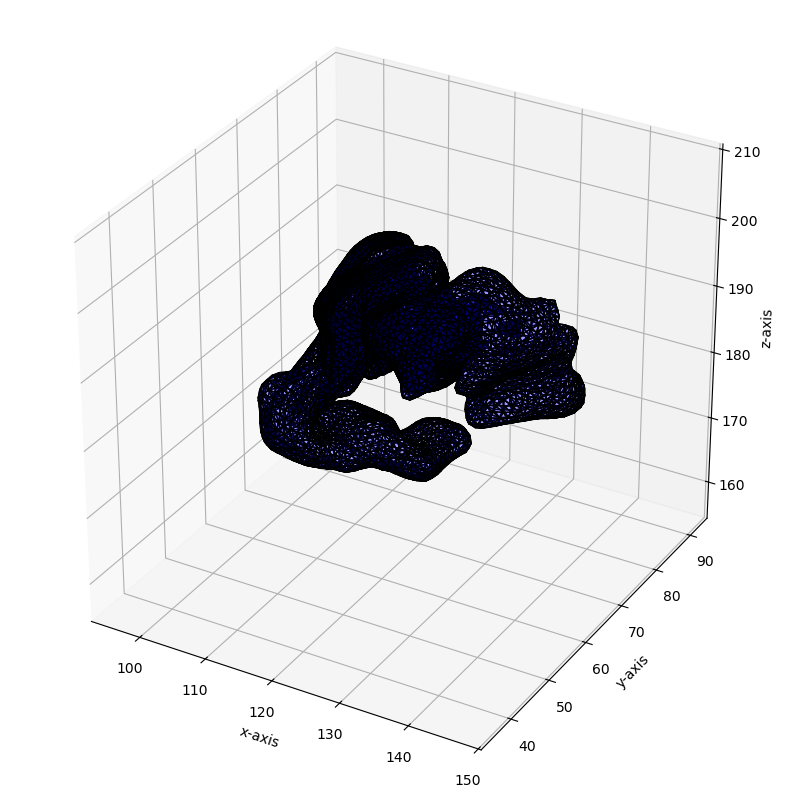

In [154]:
# Get the path to your test image file
# test_image_path = r'C:\Users\dpado\Documents\python\delaunay\test\BLSA_1537_r.img'
test_image_path = '/home/dpadova1/projects/python/delaunay/test/BLSA_1537_r.img'

# minimum_distance = '1.1'
minimum_distance = '0.8'
verbose=True
F, V = seg2surf(test_image_path, minimum_distance)

# print('np.asarray(F).shape:', np.asarray(F).shape)
print('F.shape:', F.shape)
print('V.shape:', V.shape)

plot_surface(V,F)

In [155]:
# unique undirected edges
E = np.sort(np.vstack([F[:,[0,1]], F[:,[0,2]], F[:,[1,2]]]), axis=1)
E = np.unique(E, axis=0)
chi = V.shape[0] - E.shape[0] + F.shape[0]
genus = 1 - chi/2 # #holes for a connected, orientable surface
print(f'Euler number of the surface: {chi}')
print(f'Genus of the surface: {genus}')
# euler_number = V.shape[0] - F.shape[0]/2 # Euler characteristic for triangulations of closed surfaces
# genus = 1 - euler_number/2 # #holes for a connected, orientable surface
# print(f'Euler number of the surface: {euler_number}')
# print(f'Genus of the surface: {genus}')

mesh = pv.make_tri_mesh(V,F)
print(f'Euler number of the surface [pyvista]: {mesh.n_points - mesh.extract_all_edges().n_cells + mesh.n_cells}')


Euler number of the surface: -4
Genus of the surface: 3.0
Euler number of the surface [pyvista]: -4


In [59]:
# Extract feature edges
edges = mesh.extract_feature_edges()

# Access the different types of edges
boundary_edges = edges.select_enclosed_points(mesh.select_none(mesh.select_boundary()))
non_manifold_edges = edges.select_enclosed_points(mesh.select_none(mesh.select_non_manifold()))
feature_edges = edges.select_enclosed_points(mesh.select_none(mesh.select_feature_edges()))
manifold_edges = edges.select_enclosed_points(mesh.select_none(mesh.select_manifold_edges()))

# Check the number of non-manifold edges
print(f"Number of non-manifold edges: {len(non_manifold_edges.points)}")


AttributeError: 'PolyData' object has no attribute 'select_none'

Starting C:\Users\dpado\Documents\python\delaunay\test\BLSA_1537_r.img
About to smooth
About to upsample
About to create isosurface
Spacing (dx_z, dx_y, dx_x): (0.5, 0.5, 0.5)
Number of isosurface vertices: (44482, 3)
Number of isosurface faces: (88984, 3)
Surface area of isosurface: 7385.045504876216
About to triangulate
T.shape: (52298, 4)
DT.coplanar.shape: (0, 3)
Number of original selected vertices: 7677
T.shape: (52298, 4)
VT.vertices.shape: (46431, 3)
len(VT.regions): 7685
VT.point_region.shape: (7685,)


C:\Users\dpado\AppData\Local\Temp\ipykernel_33692\1774675385.py:527: RuntimeWarning: divide by zero encountered in divide
  xx = np.einsum('ijk, ij->ik', V, UTb / S)
C:\Users\dpado\AppData\Local\Temp\ipykernel_33692\1774675385.py:527: RuntimeWarning: invalid value encountered in divide
  xx = np.einsum('ijk, ij->ik', V, UTb / S)


circumcenters.shape: (52298, 3)
About to write out
Writing file BLSA_1537_r_label01.vtk
F.shape: (15398, 3)
V.shape: (7675, 3)


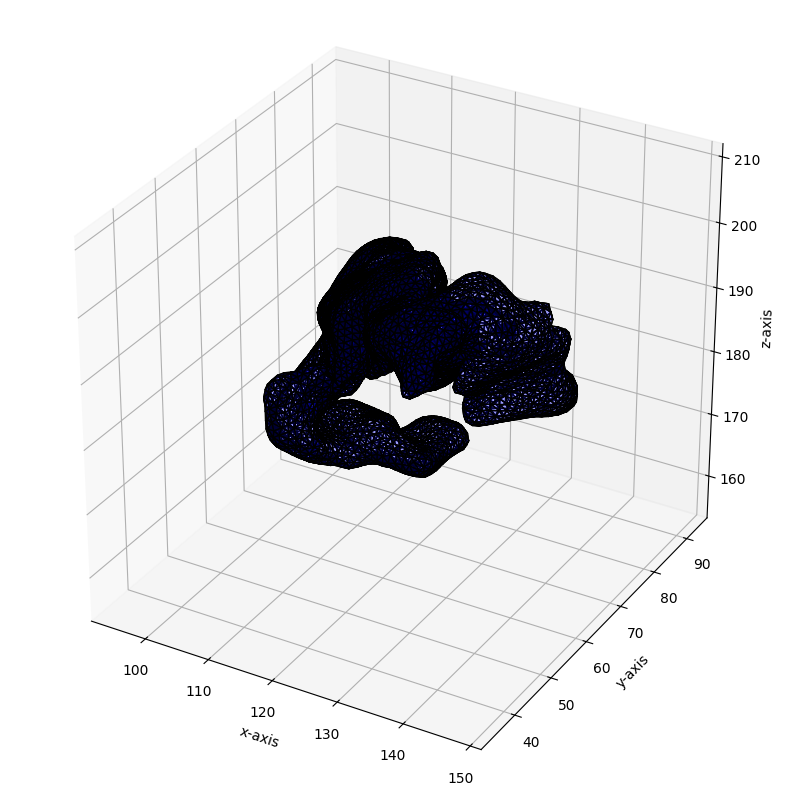

In [37]:
# Get the path to your test image file
test_image_path = r'C:\Users\dpado\Documents\python\delaunay\test\BLSA_1537_r.img'

# minimum_distance = '1.1'
minimum_distance = '0.8'
F, V = seg2surf(test_image_path, minimum_distance)

# print('np.asarray(F).shape:', np.asarray(F).shape)
print('F.shape:', F.shape)
print('V.shape:', V.shape)

plot_surface(V,F)

In [38]:
output_surface_path = rf'C:\Users\dpado\Documents\python\delaunay\test\BLSA_1537_r_dmin_{minimum_distance}.stl'
write_surface(V, F, output_surface_path)

In [34]:
# Load the image using nibabel
img = nib.load(test_image_path)
I_data = img.get_fdata()

# Extract labels
labels = np.unique(I_data)
Fsave = []
Vsave = []

for l in labels:
    if l == 0:
        # 0 is always background, we don't want this
        continue

    # If there are many labels, this is probably a smooth image
    segMax = 100
    if len(labels) > segMax:
        print(f"Warning: More than {segMax} labels, interpreting as non-binary segmentation.")
        I = I_data.astype(np.float64)
    else:
        # Otherwise, pick this label
        I = (I_data == l).astype(np.float64)

    # Get the size and voxel dimensions
    dx = img.header.get_zooms()[:3]
    nx = I.shape  # Shape is (ny, nx, nz)

    # First, subcube with 3 voxel buffer
    zsum = np.sum(I, axis=(0, 1))
    z_nonzero = np.nonzero(zsum)[0]
    if z_nonzero.size == 0:
        continue
    zmin = max(z_nonzero[0] - 3, 0)
    zmax = min(z_nonzero[-1] + 3, nx[2] - 1)

    ysum = np.sum(I, axis=(1, 2))
    y_nonzero = np.nonzero(ysum)[0]
    if y_nonzero.size == 0:
        continue
    ymin = max(y_nonzero[0] - 3, 0)
    ymax = min(y_nonzero[-1] + 3, nx[0] - 1)

    xsum = np.sum(I, axis=(0, 2))
    x_nonzero = np.nonzero(xsum)[0]
    if x_nonzero.size == 0:
        continue
    xmin = max(x_nonzero[0] - 3, 0)
    xmax = min(x_nonzero[-1] + 3, nx[1] - 1)

    # Extract the subvolume
    I = I[ymin:ymax+1, xmin:xmax+1, zmin:zmax+1]
    x0 = np.array([xmin, ymin, zmin]) * dx  # Origin adjustment

    nx = [I.shape[1], I.shape[0], I.shape[2]]  # [nx, ny, nz]
    x = np.arange(nx[0]) * dx[0] + x0[0]
    y = np.arange(nx[1]) * dx[1] + x0[1]
    z = np.arange(nx[2]) * dx[2] + x0[2]

    # Smooth it by 1 voxel
    print('About to smooth')
    smooth = 1
    I = gaussian_filter(I, sigma=smooth)

    # Upsample to uniform, twice resolution of smallest dx
    upsample = True
    if upsample:
        print('About to upsample')
        dx_min = min(dx)
        dx_new = dx_min / 2.0
        new_shape = (
            int(I.shape[0] * dx[1] / dx_new),
            int(I.shape[1] * dx[0] / dx_new),
            int(I.shape[2] * dx[2] / dx_new)
        )
        I = np.squeeze(resize(I, new_shape, order=1, mode='constant', cval=0, anti_aliasing=True))
        dx = np.array([dx_new, dx_new, dx_new])
        nx = [I.shape[1], I.shape[0], I.shape[2]]
        x = np.arange(nx[0]) * dx[0] + x0[0]
        y = np.arange(nx[1]) * dx[1] + x0[1]
        z = np.arange(nx[2]) * dx[2] + x0[2]

    # Triangulate
    print('About to create isosurface')
    # Spacing should correspond to (dx_z, dx_y, dx_x)
    spacing = (dx[2], dx[1], dx[0])  # (dz, dy, dx)
    verts, faces, _, _ = marching_cubes(I, level=np.max(I)/2, spacing=spacing)

# output_surface_path = r'C:\Users\dpado\Documents\python\delaunay\test\BLSA_1537_r.stl'
output_surface_path = r'C:\Users\dpado\Documents\python\delaunay\test\BLSA_1537_r_mc.stl'

write_surface(verts, faces, output_surface_path)

About to smooth
About to create isosurface


ValueError: Input volume should be a 3D numpy array.

In [ ]:
# Poisson sampling 
# https://colab.research.google.com/drive/1sHz28IHw3VfO2s6uim4CwaSc05idraP_?usp=sharing
# https://www.open3d.org/docs/release/tutorial/geometry/mesh.html
# from scipy.stats import qmc

# rng = np.random.default_rng()
# radius = 0.2
# engine = qmc.PoissonDisk(d=2, radius=radius, seed=rng)
# sample = engine.random(20)

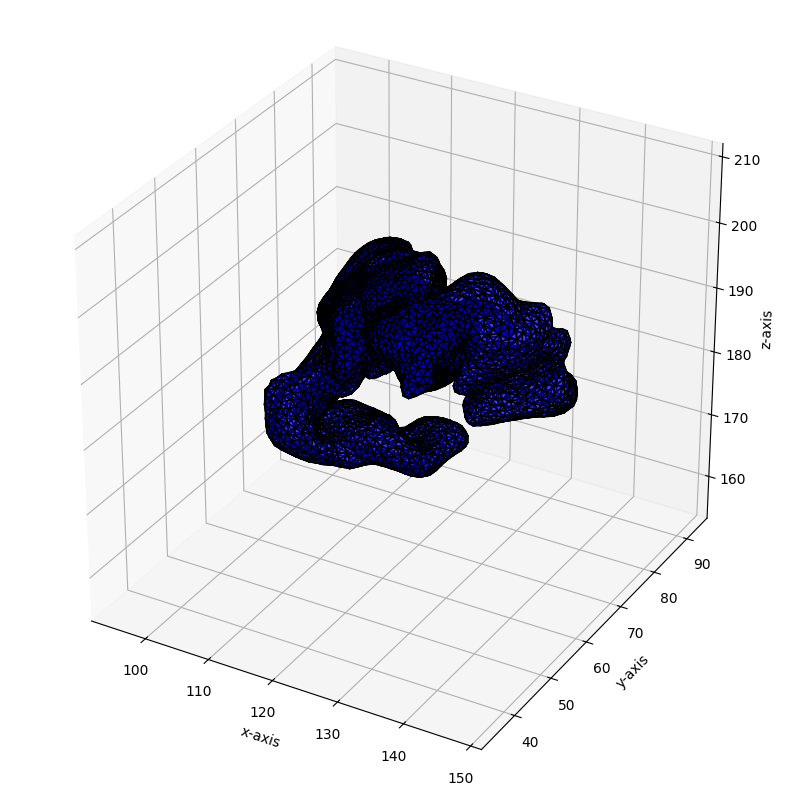

In [9]:
plot_surface(V,np.asarray(F))